# Worksheet 3 – Modelling the Neuron
## 6CS012 – Artificial Intelligence and Machine Learning

# 1. Introduction
## Aim
In this worksheet, we study:
- the McCulloch-Pitts (MCP) neuron,
- its use in simple Boolean functions such as AND and OR,
- the limitations of MCP neurons,
- and the Perceptron learning algorithm for binary classification.

We will first implement MCP neurons for logic gates, and then implement a Perceptron model from scratch to classify MNIST digits.

# 2. Task 1 — Implementation of MCP Neurons
The worksheet asks us to design MCP neurons for AND and OR using two inputs. The basic rule is:

add the two inputs

compare the sum to a threshold

output 1 if the threshold is met, otherwise 0

## 2.1 MCP Neuron for AND Gate
Markdown explanation

### MCP Neuron for AND Gate

The AND gate returns 1 only when both inputs are 1.

Truth table:

| X1 | X2 | Output |
|----|----|--------|
| 0  | 0  |   0    |
| 0  | 1  |   0    |
| 1  | 0  |   0    |
| 1  | 1  |   1    |

For the MCP implementation:
- we add the two inputs,
- if the sum is greater than or equal to threshold 2, output is 1,
- otherwise output is 0.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements the AND operation using an MCP neuron.

    Parameters:
    X1 : list
        First input list containing binary values (0 or 1).
    X2 : list
        Second input list containing binary values (0 or 1).
    T : int
        Threshold value.

    Returns:
    state_neuron : list
        Output list containing 0 or 1 for each input pair.
    """

    # Make sure both input lists are of equal length
    assert len(X1) == len(X2), "Input lists must have the same length."

    # This list will store the output of the neuron for each input pair
    state_neuron = []

    # Loop through both input lists together
    for x1, x2 in zip(X1, X2):
        # Step 1: Aggregate inputs by summing them
        total_input = x1 + x2

        # Step 2: Compare the sum with the threshold
        if total_input >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage for AND gate
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold for AND gate

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND gate output:", result_and)

AND gate output: [0, 0, 0, 1]


### Explanation of the code
- `assert len(X1) == len(X2)` checks that both input lists have the same number of elements.
- `state_neuron = []` creates an empty list to store outputs.
- `for x1, x2 in zip(X1, X2):` loops through corresponding elements of both lists.
- `total_input = x1 + x2` adds the two inputs.
- `if total_input >= T:` checks whether the threshold is reached.
- If yes, append `1`; otherwise append `0`.

For AND, we use `T = 2` because only `1 + 1 = 2` should produce output 1.

##2.2 MCP Neuron for OR Gate


## MCP Neuron for OR Gate

The OR gate returns 1 if at least one input is 1.

Truth table:

| X1 | X2 | Output |
|----|----|--------|
| 0  | 0  |   0    |
| 0  | 1  |   1    |
| 1  | 0  |   1    |
| 1  | 1  |   1    |

For the MCP implementation:
- we add the inputs,
- if the sum is greater than or equal to threshold 1, output is 1,
- otherwise output is 0.

In [2]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements the OR operation using an MCP neuron.

    Parameters:
    X1 : list
        First input list containing binary values (0 or 1).
    X2 : list
        Second input list containing binary values (0 or 1).
    T : int
        Threshold value.

    Returns:
    state_neuron : list
        Output list containing 0 or 1 for each input pair.
    """

    # Make sure both input lists are of equal length
    assert len(X1) == len(X2), "Input lists must have the same length."

    # This list stores the neuron outputs
    state_neuron = []

    # Iterate through input pairs
    for x1, x2 in zip(X1, X2):
        # Aggregate both inputs
        total_input = x1 + x2

        # Apply threshold rule
        if total_input >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage for OR gate
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold for OR gate

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR gate output:", result_or)

OR gate output: [0, 1, 1, 1]


### Explanation of the code
This code works exactly like the AND example, except the threshold is different.

For OR, the threshold is `1`, because:
- `0 + 1 = 1` should give output 1
- `1 + 0 = 1` should give output 1
- `1 + 1 = 2` should also give output 1
- only `0 + 0 = 0` should give output 0

##2.3 Answers for Task 1 Questions
Question 1: List out all the limitations of MCP neurons.
## Limitations of MCP Neurons

The MCP neuron has several important limitations:

1. **No learning ability**  
   The threshold is manually chosen. The model cannot learn weights or thresholds from data.

2. **Very simple decision rule**  
   It only works using a fixed threshold on summed inputs.

3. **Cannot handle complex patterns**  
   It is suitable only for simple logical problems like AND and OR.

4. **Cannot solve XOR with a single neuron**  
   XOR is not linearly separable, so a single MCP neuron cannot represent it.

5. **No trainable weights**  
   All inputs are treated equally in the simplest MCP form.

6. **Binary input/output only**  
   It is restricted to simple binary values and cannot naturally model richer continuous data.

7. **Biologically oversimplified**  
   It is only a very rough abstraction of a real neuron.

Question 2: Can you develop a logic to solve XOR using MCP Neuron?
## Can MCP Neuron Solve XOR?

A **single MCP neuron cannot solve XOR** because XOR is not linearly separable.

XOR truth table:

| X1 | X2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

There is no single threshold on `X1 + X2` that gives this pattern:
- sum = 0 → output 0
- sum = 1 → output 1
- sum = 2 → output 0

So, a single MCP neuron is not enough.

However, XOR can be built by combining multiple neurons, for example:
- one neuron for OR,
- one neuron for AND,
- and a final rule combining them.

A common logical form is:

XOR = (X1 OR X2) AND NOT(X1 AND X2)

#3. Task 2 — Perceptron Algorithm for 0 vs 1 Classification

The worksheet asks you to implement a Perceptron for MNIST digits 0 and 1, load the dataset, initialize weights and bias, define a decision function, train the perceptron, and visualize misclassified images.

##3.1 Import Libraries and Load Dataset
## Load the Dataset

We load the MNIST subset containing only digits 0 and 1.

- Each image is represented as 784 pixel values because each image is 28 × 28.
- The label column contains the class: either 0 or 1.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
# In Colab, upload the file first and make sure the file path is correct
df_0_1 = pd.read_csv("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Dataset/mnist_0_and_1.csv")

# Separate features and labels
X = df_0_1.drop(columns=["label"]).values   # 784 pixel values per image
y = df_0_1["label"].values                  # labels: 0 or 1

# Print shapes to understand the dataset size
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Explanation of the code
- `pd.read_csv(...)` reads the CSV file into a pandas DataFrame.
- `drop(columns=["label"])` removes the label column, leaving only image pixels.
- `.values` converts the DataFrame into a NumPy array.
- `X` contains the input images.
- `y` contains the correct class labels.
- `X.shape` tells us the number of samples and features.
- `y.shape` tells us how many labels are present.

##3.2 Answers for Dataset Shape Questions
Question 1: What does the shape of X represent?

## Answer: Shape of X

The shape of `X` is `(number_of_samples, number_of_features)`.

For example, if `X.shape = (200, 784)`, it means:
- there are 200 images in the dataset,
- each image has 784 features,
- and these 784 features correspond to the 28 × 28 = 784 pixel values.

Question 2: What does the shape of y represent?

## Answer: Shape of y

The shape of `y` is `(number_of_samples,)`.

This means there is one label for each image in `X`.
So, if `y.shape = (200,)`, then there are 200 labels, one for each sample.

##3.3 Visualize Sample Images

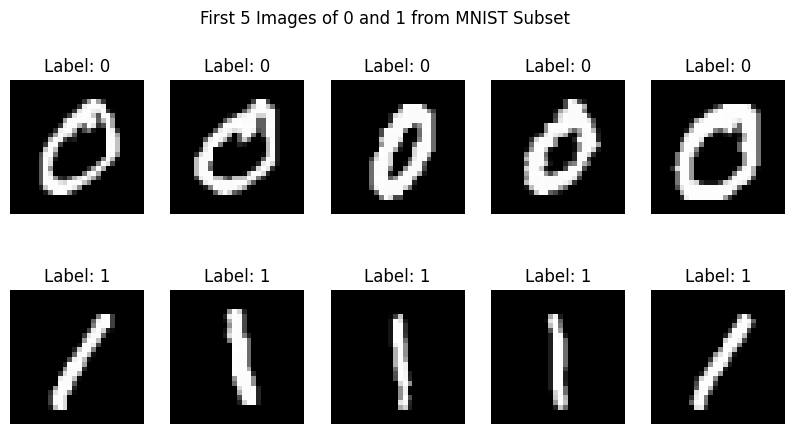

In [5]:
# Separate images of class 0 and class 1
images_0 = X[y == 0]
images_1 = X[y == 1]

# Create a 2 x 5 grid of plots
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check whether we have enough images to display
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Display digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Display digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

### Explanation of the code
- `X[y == 0]` selects only those rows whose label is 0.
- `X[y == 1]` selects only those rows whose label is 1.
- `plt.subplots(2, 5, figsize=(10, 5))` creates a figure with 2 rows and 5 columns.
- `.reshape(28, 28)` converts the flat 784-pixel vector back into a 28 × 28 image.
- `cmap="gray"` displays the image in grayscale.
- `axis("off")` hides axis ticks for cleaner visualization.

##3.4 Initialize Weights and Bias

In [6]:
# Initialize parameters for the perceptron
weights = np.zeros(X.shape[1])   # One weight for each feature (pixel)
bias = 0                         # Bias term
learning_rate = 0.1              # Step size for updates
epochs = 100                     # Number of times to iterate through the dataset

### Explanation of the code
- `np.zeros(X.shape[1])` creates a weight vector of length 784.
- Each weight corresponds to one pixel position.
- `bias = 0` initializes the bias term.
- `learning_rate` controls how much the weights change when there is a mistake.
- `epochs` tells the model how many full passes to make through the dataset.

##3.5 Answers for Weight Initialization Questions
Question 3: What does the weights array represent?

## Answer: What does the weights array represent?

The `weights` array stores the importance of each input feature (pixel).

Since each image has 784 pixels, the perceptron learns 784 weights:
- a positive weight means that pixel supports one class,
- a negative or smaller weight means that pixel contributes less or pushes toward the other class.

In simple terms, the weights tell the model how strongly each pixel influences the final decision.

Question 4: Why initialize the weights to zero? What effect could this have?

## Answer: Why initialize weights to zero?

We initialize the weights to zero because it is simple and gives a neutral starting point.

Effect on training:
- At the beginning, the model has no preference for either class.
- During training, the weights are updated based on mistakes.
- For a perceptron, zero initialization is usually acceptable because the model still updates correctly as it sees examples.

In deeper neural networks, zero initialization can be problematic because all neurons may learn the same thing, but for a single perceptron it is generally fine.

##3.6 Decision / Activation Function
The worksheet asks for a step function that returns class labels using the learned weights and bias.

In [7]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the perceptron decision rule.

    Parameters:
    X : numpy array
        Input feature matrix of shape (n_samples, n_features)
    weights : numpy array
        Learned weight vector
    bias : float
        Learned bias term

    Returns:
    y_pred_all : numpy array
        Predicted labels (0 or 1)
    """

    # Compute the linear score: weighted sum of inputs + bias
    predictions = np.dot(X, weights) + bias

    # Apply the step activation function:
    # if score >= 0, predict 1; else predict 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

### Explanation of the code
- `np.dot(X, weights)` computes the weighted sum of features for each sample.
- `+ bias` shifts the decision boundary.
- `np.where(predictions >= 0, 1, 0)` applies the step function:
  - output `1` when the score is non-negative,
  - otherwise output `0`.

This converts the continuous score into a binary class prediction.

##3.7 Perceptron Training Function

In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    X : numpy array
        Input feature matrix of shape (n_samples, n_features)
    y : numpy array
        True labels of shape (n_samples,)
    weights : numpy array
        Initial weight vector
    bias : float
        Initial bias
    learning_rate : float
        Learning rate for updates
    epochs : int
        Number of full training passes through the dataset

    Returns:
    weights : numpy array
        Updated weights after training
    bias : float
        Updated bias after training
    accuracy : float
        Final training accuracy
    """

    # Repeat training for the specified number of epochs
    for epoch in range(epochs):
        correct_predictions = 0

        # Go through each training sample one by one
        for i in range(len(X)):
            # Compute linear output for sample i
            output = np.dot(X[i], weights) + bias

            # Apply step function to get predicted class
            y_pred = 1 if output >= 0 else 0

            # If prediction is correct, count it
            if y_pred == y[i]:
                correct_predictions += 1
            else:
                # If prediction is wrong, compute the error
                error = y[i] - y_pred

                # Update weights
                # Each weight is adjusted based on:
                # learning rate × error × input feature
                weights = weights + learning_rate * error * X[i]

                # Update bias
                bias = bias + learning_rate * error

        # Calculate accuracy after each epoch
        accuracy = correct_predictions / len(X)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.4f}")

        # Optional early stopping if perfect classification is reached
        if accuracy == 1.0:
            print("Training converged early because all samples were classified correctly.")
            break

    return weights, bias, accuracy

### Explanation of the code
This is the main learning part of the perceptron.

1. The algorithm loops over the dataset multiple times using epochs.
2. For each sample:
   - it computes the weighted sum,
   - applies the step function,
   - compares prediction with the true label.
3. If the prediction is wrong:
   - the error is calculated as `true label - predicted label`,
   - weights are updated,
   - bias is updated.
4. Over time, these updates move the decision boundary so the model makes fewer mistakes.

##3.8 Answer for Question 5
Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?

## Answer: Purpose of `output = np.dot(X[i], weights) + bias`

This line computes the **linear score** or **net input** for the `i-th` sample.

- `np.dot(X[i], weights)` multiplies each feature by its weight and adds them together.
- `+ bias` shifts the result.

This value is then passed through the step function to decide whether the sample belongs to class 0 or class 1.

So, this line is the core computation that determines the perceptron’s prediction.

##3.9 Answer for Question 6
Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

## Answer: What happens when prediction is wrong?

When the prediction is wrong:
1. The error is computed:
   `error = y[i] - y_pred`

2. The weights are updated using:
   `weights = weights + learning_rate * error * X[i]`

3. The bias is updated using:
   `bias = bias + learning_rate * error`

Why this helps:
- If the model predicts too low, the update increases the score for similar samples.
- If the model predicts too high, the update decreases the score.

This gradually adjusts the decision boundary so the perceptron classifies the training data better.

##3.10 Answer for Question 7
Question 7: Why is the final accuracy important, and what do you expect it to be?

## Answer: Why is final accuracy important?

Final accuracy tells us how well the perceptron has learned to classify the dataset.

It is important because:
- it measures performance,
- it shows whether training was successful,
- it helps us judge whether the classes are linearly separable.

For digit classification of **0 vs 1**, I expect the accuracy to be **very high**, often close to 1.0, because digits 0 and 1 are usually easy to separate with a linear classifier.

If the dataset is clean, the perceptron may even classify all samples correctly.

##3.11 Train the Perceptron

In [10]:
# Train the perceptron
weights, bias, accuracy = train_perceptron(
    X, y, weights, bias, learning_rate=learning_rate, epochs=epochs
)

print("The Final Accuracy is:", accuracy)

Epoch 1/100, Accuracy: 0.9967
Epoch 2/100, Accuracy: 0.9982
Epoch 3/100, Accuracy: 0.9987
Epoch 4/100, Accuracy: 0.9987
Epoch 5/100, Accuracy: 0.9990
Epoch 6/100, Accuracy: 0.9993
Epoch 7/100, Accuracy: 0.9998
Epoch 8/100, Accuracy: 0.9995
Epoch 9/100, Accuracy: 0.9989
Epoch 10/100, Accuracy: 0.9992
Epoch 11/100, Accuracy: 0.9995
Epoch 12/100, Accuracy: 0.9998
Epoch 13/100, Accuracy: 1.0000
Training converged early because all samples were classified correctly.
The Final Accuracy is: 1.0


##3.12 Visualize Misclassified Images
The worksheet asks you to visualize incorrect predictions after training.

In [11]:
# Get final predictions for the whole dataset
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Compute final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Find indices where prediction is incorrect
misclassified_idx = np.where(y_pred != y)[0]

# Display misclassified images if any exist
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show first 10 mistakes
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


### Explanation of the code
- `predictions = np.dot(X, weights) + bias` computes the raw scores for all samples.
- `np.where(predictions >= 0, 1, 0)` converts scores into class labels.
- `np.mean(y_pred == y)` computes the proportion of correct predictions.
- `np.where(y_pred != y)[0]` finds the indices of incorrectly classified images.
- These indices are used to display the images the model got wrong.
- If there are no mistakes, the code prints that all images were correctly classified.

##3.13 Answers for Questions 8 and 9
Question 8: What does misclassified_idx store, and how is it used?

## Answer: What does `misclassified_idx` store?

`misclassified_idx` stores the indices of all samples where the predicted label is different from the true label.

It is used to:
- locate the wrongly classified images,
- display them using `imshow`,
- and help us analyze where the model is making mistakes.

Question 9: How do you interpret “All images were correctly classified!”?

## Answer: Interpretation of “All images were correctly classified!”

This means the perceptron made no mistakes on the dataset being evaluated.

Interpretation:
- the final accuracy is 100%,
- the classes are likely linearly separable in this dataset,
- the perceptron learned a decision boundary that correctly separates all samples in the evaluated data.

For 0 vs 1, this is possible because those digits are often easier to separate.

#4. Task 3 — Perceptron Algorithm for 3 vs 5 Classification

The worksheet asks you to repeat the same perceptron process for digits 3 and 5 and then visualize misclassified images and provide a conclusion.

##4.1 Load the 3 vs 5 Dataset

In [12]:
# Load dataset for digits 3 and 5
df_3_5 = pd.read_csv("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Dataset/mnist_3_and_5.csv")

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


##4.2 Visualize Sample Images of 3 and 5

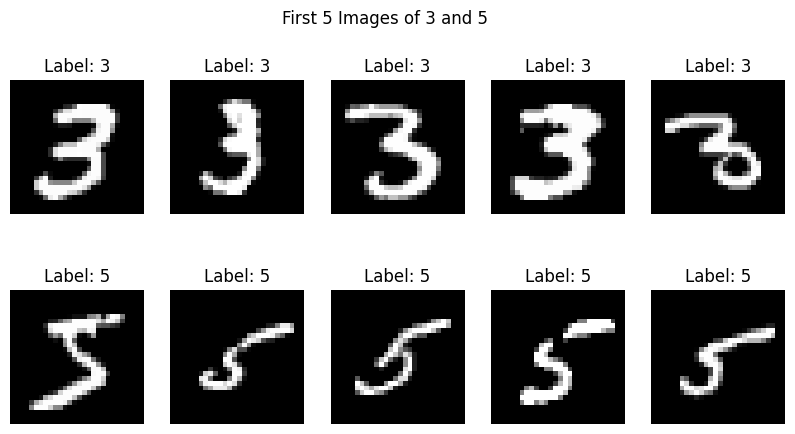

In [13]:
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5")
plt.show()

##4.3 Convert Labels to Binary for Perceptron

Because the perceptron code predicts 0 or 1, convert:

3 -> 0

5 -> 1

In [14]:
# Convert labels to binary classes for perceptron training
y_35_binary = np.where(y_35 == 5, 1, 0)

## Why convert labels?

The perceptron implementation outputs only binary labels: 0 or 1.

So we remap:
- digit 3 to class 0
- digit 5 to class 1

This allows us to use the same training code as before.

##4.4 Train Perceptron on 3 vs 5

In [15]:
# Initialize weights and bias
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0

# Train the model
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35, learning_rate=0.1, epochs=100
)

print("Final Accuracy for 3 vs 5:", accuracy_35)

Epoch 1/100, Accuracy: 0.9157
Epoch 2/100, Accuracy: 0.9372
Epoch 3/100, Accuracy: 0.9416
Epoch 4/100, Accuracy: 0.9475
Epoch 5/100, Accuracy: 0.9489
Epoch 6/100, Accuracy: 0.9504
Epoch 7/100, Accuracy: 0.9599
Epoch 8/100, Accuracy: 0.9559
Epoch 9/100, Accuracy: 0.9540
Epoch 10/100, Accuracy: 0.9566
Epoch 11/100, Accuracy: 0.9599
Epoch 12/100, Accuracy: 0.9580
Epoch 13/100, Accuracy: 0.9657
Epoch 14/100, Accuracy: 0.9602
Epoch 15/100, Accuracy: 0.9635
Epoch 16/100, Accuracy: 0.9657
Epoch 17/100, Accuracy: 0.9606
Epoch 18/100, Accuracy: 0.9624
Epoch 19/100, Accuracy: 0.9610
Epoch 20/100, Accuracy: 0.9661
Epoch 21/100, Accuracy: 0.9701
Epoch 22/100, Accuracy: 0.9690
Epoch 23/100, Accuracy: 0.9730
Epoch 24/100, Accuracy: 0.9683
Epoch 25/100, Accuracy: 0.9650
Epoch 26/100, Accuracy: 0.9715
Epoch 27/100, Accuracy: 0.9734
Epoch 28/100, Accuracy: 0.9694
Epoch 29/100, Accuracy: 0.9715
Epoch 30/100, Accuracy: 0.9726
Epoch 31/100, Accuracy: 0.9668
Epoch 32/100, Accuracy: 0.9715
Epoch 33/100, Acc

##4.5 Visualize Misclassified Images for 3 vs 5

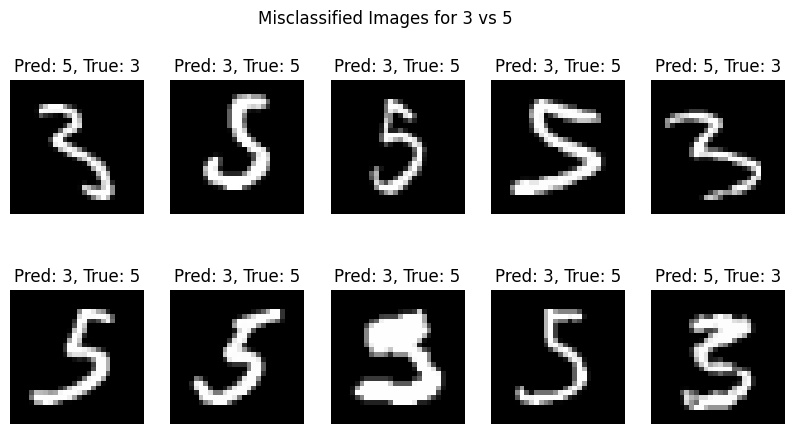

In [16]:
# Predict on the full dataset
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

# Convert predictions back to original digit labels for display
predicted_digits = np.where(y_pred_35 == 1, 5, 3)

# Find misclassified indices
misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

# Show misclassified samples
if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {predicted_digits[idx]}, True: {y_35[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

##4.6 Conclusion for Task 3
### Conclusion for 3 vs 5 Classification

The perceptron performs binary classification by learning a linear decision boundary.

Compared with 0 vs 1 classification, the 3 vs 5 classification task is usually more difficult because:
- digits 3 and 5 are visually more similar,
- some handwritten samples may overlap in shape,
- a single perceptron can only learn a linear boundary.

Therefore, I expect:
- lower accuracy than 0 vs 1 classification,
- more misclassified images,
- and errors mainly on ambiguous handwritten digits.

This demonstrates one important limitation of the perceptron: it works well only when the two classes are approximately linearly separable.

# Final Summary

In this worksheet, I implemented:
1. MCP neurons for AND and OR gates
2. A discussion of MCP neuron limitations
3. A perceptron model for classifying digits 0 and 1
4. A perceptron model for classifying digits 3 and 5

## Key Learnings
- MCP neurons are simple threshold-based models.
- They can implement basic logic functions like AND and OR.
- They cannot learn from data and cannot solve XOR using a single neuron.
- The perceptron improves on MCP by introducing trainable weights and a bias.
- The perceptron updates its parameters whenever it makes a wrong prediction.
- It works well for linearly separable binary classification tasks.
- More difficult digit pairs like 3 and 5 may lead to more classification errors.